# Companion code to the paper

*A Martingale Approach To Fluctuations of Rank Estimators in Sensitivity Analysis*
by **R. Chhaibi, F. Gamboa and C. Pellegrini**

This notebook reproduces the numerical validation of Appendix C of the paper.
Section 1 (Ishigami model) produces Figure C.1, Section 2 (Gaussian model)
Figures C.2 and C.3, and Section 3 (random support model) Figure C.4.


In [1]:
# We import here all the necessary libraries
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import latex
from scipy.stats import pearsonr
from scipy.integrate import dblquad
from concurrent.futures import ThreadPoolExecutor

In [2]:
# Machine-dependent settings. They affect running time only, never results.
# Tuned on a 14-core / 20-thread laptop with 30 GB of memory; re-tune elsewhere.
hardware_options = {
    "n_threads": 16,    # threads the parameter grid is spread over; 1 for a serial run
    "batch_size": 25,   # repetitions per block; small so that a block stays in cache
}

## 1. Ishigami model (Sobol' index)

The Ishigami model is the real function $f$ below with three independent random inputs $X_1, X_2, X_3$ and depending on the two real parameters $a,b$. The random inputs are uniformly distributed on $(-\pi, \pi)$.  
$$f(X_1,X_2,X_3)= \sin(X_1) + a \sin^2(X_2) + b X_3^4 \sin(X_1),\;\; (a,b\in\mathbb{R}).$$

### 1.1 Formal computations
In this part, we compute formally both the Sobol' index associated with $X_1$ and the asymptotic variance of the Chatterjee estimator provided in Theorem 2.1.

In [3]:
# Function that integrates a symbolic function ff over the variable x in (-pi,pi)
# using the normalized Lebesgue measure
def expectation(ff, x):

#    ff : sympy expression
#        Function to integrate
#    x : sympy symbol

    return sp.integrate(ff, (x, -sp.pi, sp.pi))/ (2*sp.pi)

In [4]:
# Symbolic variables definition
x1, x2, x3 = sp.symbols('x1 x2 x3')
a, b = sp.symbols('a b')

In [5]:
# Defining Ishigami function and its square 
f = sp.sin(x1) + a * sp.sin(x2)**2 + b * x3**4 * sp.sin(x1)
f2=f*f

In [6]:
# Conditional expectation of f given X1=x1
conditional_expectation_f = expectation(expectation(f, x3), x2)
# Conditional expectation of f² given X1=x1
conditional_expectation_f2 = expectation(expectation(f2, x3), x2)

In [7]:
# Computing Sigma0, Eq. (2.7): the covariance of the vector
# (E_eps[f]^2, E_eps[f], E_eps[f^2])
moment_vector = sp.Matrix([conditional_expectation_f*conditional_expectation_f,
                           conditional_expectation_f,
                           conditional_expectation_f2])
# Computing the centering part
moment_vector_mean = expectation(moment_vector, x1)
Sigma0_centering = moment_vector_mean*moment_vector_mean.T
# Computing the quadratic part before integrating with respect to x1
moment_vector_outer = moment_vector*moment_vector.T
# Computing the covariance matrix Sigma0
Sigma0 = expectation(moment_vector_outer, x1) - Sigma0_centering

In [8]:
# Computing Sigma_a, Eq. (2.8)
sigma_a_vector = sp.Matrix([2*conditional_expectation_f, 1, 1])
e1 = sp.Matrix([1, 0, 0])
e1_outer = e1*e1.T
conditional_covariance_f = (conditional_expectation_f2
                            - conditional_expectation_f*conditional_expectation_f)
Sigma_a = sigma_a_vector*sigma_a_vector.T + conditional_covariance_f*e1_outer

In [9]:
# Computing Sigma_b, Eq. (2.9): the conditional covariance of (f, f, f^2)
sigma_b_vector = sp.Matrix([f, f, f2])
# Conditional expectation of that vector
sigma_b_vector_mean = sp.Matrix([conditional_expectation_f,
                                 conditional_expectation_f,
                                 conditional_expectation_f2])
sigma_b_vector_outer = sigma_b_vector*sigma_b_vector.T
Sigma_b = (expectation(expectation(sigma_b_vector_outer, x2), x3)
           - sigma_b_vector_mean*sigma_b_vector_mean.T)

In [10]:
# Computing Sigma1, Eq. (2.10)
# Integrand: Hadamard product of Sigma_a and Sigma_b
Sigma1_integrand = sp.hadamard_product(Sigma_a, Sigma_b)
# Finally integrating with respect to x1
Sigma1 = expectation(Sigma1_integrand, x1)

In [11]:
# Formal computation of the variance of f and of the Sobol' index for X1
# Expectation of f
mean_f = expectation(conditional_expectation_f, x1)
# Expectation of f²
mean_f2 = expectation(conditional_expectation_f2, x1)
# Variance of f
var_Y = mean_f2 - mean_f*mean_f
# Variance of the conditional expectation
sobol_numerator = expectation(conditional_expectation_f*conditional_expectation_f, x1) - mean_f*mean_f
# Computing the Sobol' index
sobol_index = sp.simplify(sobol_numerator/var_Y)
# Give the Sobol' index expression
sp.pprint(sp.simplify(sobol_index))
# Give the Sobol' index expression in latex format
print(latex(sp.simplify(sobol_index)))

        ⎛ 8  2       4       ⎞      
     36⋅⎝π ⋅b  + 10⋅π ⋅b + 25⎠      
────────────────────────────────────
  ⎛    2       8  2       4        ⎞
5⋅⎝45⋅a  + 20⋅π ⋅b  + 72⋅π ⋅b + 180⎠
\frac{36 \left(\pi^{8} b^{2} + 10 \pi^{4} b + 25\right)}{5 \cdot \left(45 a^{2} + 20 \pi^{8} b^{2} + 72 \pi^{4} b + 180\right)}


In [12]:
# Asymptotic variance of the Chatterjee estimator of the Sobol' index, Eq. (2.14)
v_f = (sp.Matrix([1, 2*mean_f*(sobol_index-1), -sobol_index]))/var_Y
# Asymptotic variance final formula
sigma2_sobol = sp.simplify(v_f.T*(Sigma0+Sigma1)*v_f)
# Give the latex formula of the asymptotic variance
print(latex(sp.simplify(sigma2_sobol)))

\left[\begin{matrix}\frac{3 \cdot \left(1510396875 a^{8} + 3168477000 \pi^{8} a^{6} b^{2} + 14499810000 \pi^{4} a^{6} b + 36249525000 a^{6} + 2246456160 \pi^{16} a^{4} b^{4} + 15294614400 \pi^{12} a^{4} b^{3} + 45969768000 \pi^{8} a^{4} b^{2} + 38666160000 \pi^{4} a^{4} b + 48332700000 a^{4} + 567674880 \pi^{24} a^{2} b^{6} + 3989495808 \pi^{20} a^{2} b^{5} + 12004208640 \pi^{16} a^{2} b^{4} + 17766604800 \pi^{12} a^{2} b^{3} + 41243904000 \pi^{8} a^{2} b^{2} + 48005120 \pi^{32} b^{8} + 336199680 \pi^{28} b^{7} + 1318256640 \pi^{24} b^{6} + 4554620928 \pi^{20} b^{5} + 11107860480 \pi^{16} b^{4}\right)}{1105 \cdot \left(4100625 a^{8} + 7290000 \pi^{8} a^{6} b^{2} + 26244000 \pi^{4} a^{6} b + 65610000 a^{6} + 4860000 \pi^{16} a^{4} b^{4} + 34992000 \pi^{12} a^{4} b^{3} + 150465600 \pi^{8} a^{4} b^{2} + 314928000 \pi^{4} a^{4} b + 393660000 a^{4} + 1440000 \pi^{24} a^{2} b^{6} + 15552000 \pi^{20} a^{2} b^{5} + 94867200 \pi^{16} a^{2} b^{4} + 347120640 \pi^{12} a^{2} b^{3} + 853804800 \pi^

### 1.2 Numerical evaluation

In [13]:
# Evaluating numerically the Sobol' index and the asymptotic variance for given a and b
# a_value = input('Give a value for a');
# b_value = input('Give a value for b');
a_value = 10.;
b_value = 2.
values = {a: a_value, b: b_value}
sobol_value = sobol_index.evalf(subs=values);
sigma2_sobol_value = sigma2_sobol.evalf(subs=values);
print('In the special case a=', a_value, 'and b=', b_value);
print('Sobol index is: ', sobol_value);
print('The asymptotic variance is: ', sigma2_sobol_value)

In the special case a= 10.0 and b= 2.0
Sobol index is:  0.369607256054114
The asymptotic variance is:  Matrix([[0.790209784537542]])


### 1.3 Curves for fixed $a$, varying $b$

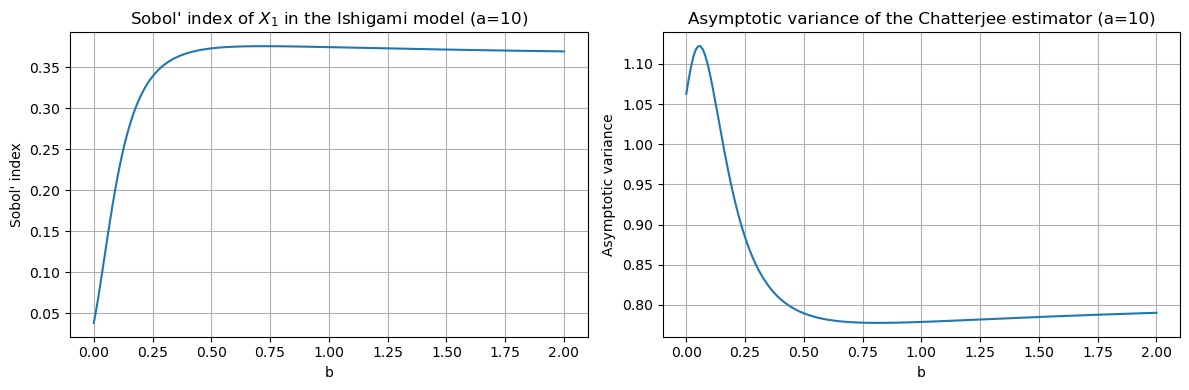

In [14]:
# Evaluating the Sobol' index and the asymptotic variance for a fixed a and a range of b
# Turning the symbolic expressions into numerical functions
sobol_fn = sp.lambdify((a, b), sobol_index, "numpy")
sigma2_sobol_fn = sp.lambdify((a, b), sigma2_sobol, "numpy")
# b moves from 0 to 2, with a fixed to 10
b_values = np.arange(0, 2.01, 0.01)
sobol_theoretical = sobol_fn(10., b_values)
sigma2_sobol_theoretical = sigma2_sobol_fn(10, b_values).reshape(-1)
# Two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ----- first plot -----
axes[0].plot(b_values, sobol_theoretical)
axes[0].set_title("Sobol' index of $X_1$ in the Ishigami model (a=10)")
axes[0].set_xlabel("b")
axes[0].set_ylabel("Sobol' index")
axes[0].grid(True)

# ----- second plot -----
axes[1].plot(b_values, sigma2_sobol_theoretical)
axes[1].set_title("Asymptotic variance of the Chatterjee estimator (a=10)")
axes[1].set_xlabel("b")
axes[1].set_ylabel("Asymptotic variance")
axes[1].grid(True)

# Adjust spacing
plt.tight_layout()
# Display
plt.show()

### 1.4 Comparison with a crude Monte Carlo experiment (Figure C.1)

In [15]:
# Pure numerical computation of the Ishigami function
def ishigami(x_sample, a=10., b=0.1):
    """
    Compute the Ishigami function for n points.

    Input parameters
    ----------
    x_sample : ndarray (3, n)
        Matrix containing the n points (each column is a point).
    a : float
        Parameter a of the Ishigami function.
    b : float
        Parameter b of the Ishigami function.

    Output
    ------
    y : ndarray of shape (n,)
        Values of the function for each input point.
    """

    x_sample = np.asarray(x_sample)

    if x_sample.shape[0] != 3:
        raise ValueError("Matrix x_sample must be of dimension (3, n).")

    x1 = x_sample[0, :]
    x2 = x_sample[1, :]
    x3 = x_sample[2, :]

    y = (
        np.sin(x1)
        + a * np.sin(x2) ** 2
        + b * x3 ** 4 * np.sin(x1)
    )


    return y

In [16]:
# Numerical computation of the first Sobol' index
def sobol_index_ishigami(a=10., b=0.1):
    """
    Numerical evaluation of the Sobol' index associated with X1

    Parameters
    ----------
    a : float
        Parameter a of the Ishigami function.
    b : float
        Parameter b of the Ishigami function.

    Output
    ------
    y : float
        Sobol' index value
    """

    y = (36*((np.pi**8)*b**2 + 10*(np.pi**4)*b + 25)
         / (5*(45*a**2 + 20*(np.pi**8)*b**2 + 72*(np.pi**4)*b + 180)))

    return y

In [17]:
# Monte Carlo design
n_repetitions = 10000;
n_samples = 10000;

#### How the Monte Carlo estimation is organised

Three choices, none of which changes the estimator:

- the ordering of $X_1$ is obtained with `argsort` on that row alone, not on all three inputs;
- the correlation is evaluated as two dot products rather than through `scipy.stats.pearsonr`,
  which also returns a $p$-value that is discarded;
- repetitions are handled in blocks of `batch_size` rows, and the $b$-grid is spread over
  `n_threads` threads. NumPy releases the GIL in `argsort`, in the generators and in the ufuncs
  used here, so threads are enough and no separate processes are needed.

Together these are worth about a factor $20$ on the machine described in `hardware_options`.
The cell after the definition checks the block implementation against the literal one.

In [18]:
# Monte Carlo estimate of the asymptotic variance at a given b, over `repetitions`
# repetitions of a sample of size `samples`. Returns that estimate together with the
# last realization of the estimator.
def estimate_sobol_variance_ishigami(b_value, sobol_true,
                                     repetitions=None, samples=None, block=None):
    repetitions = n_repetitions if repetitions is None else repetitions
    samples = n_samples if samples is None else samples
    block = hardware_options["batch_size"] if block is None else block
    rng = np.random.default_rng()          # own stream, so the call is thread-safe
    blocks = []
    for start in range(0, repetitions, block):
        n_rows = min(block, repetitions - start)
        # One repetition per row
        x1 = rng.uniform(-np.pi, np.pi, (n_rows, samples));
        x2 = rng.uniform(-np.pi, np.pi, (n_rows, samples));
        x3 = rng.uniform(-np.pi, np.pi, (n_rows, samples));
        sin_x1 = np.sin(x1)
        y_sample = sin_x1 + 10.0*np.sin(x2)**2 + b_value*x3**4*sin_x1
        # Reorder Y according to the ordering of X1
        x_sorting_order = np.argsort(x1, axis=1);
        y_sorted = np.take_along_axis(y_sample, x_sorting_order, axis=1);
        # Chatterjee's estimator, for every row at once
        y_shifted = np.zeros_like(y_sorted)
        y_shifted[:, 0:samples-1] = y_sorted[:, 1:samples];
        centered_sorted = y_sorted - y_sorted.mean(axis=1, keepdims=True)
        centered_shifted = y_shifted - y_shifted.mean(axis=1, keepdims=True)
        numerator = np.einsum('ij,ij->i', centered_sorted, centered_shifted)
        denominator = np.sqrt(np.einsum('ij,ij->i', centered_sorted, centered_sorted)
                              * np.einsum('ij,ij->i', centered_shifted, centered_shifted))
        blocks.append(numerator/denominator)
    estimates = np.concatenate(blocks)
    variance_estimate = samples*np.var(estimates - sobol_true)
    return variance_estimate, estimates[-1]

In [19]:
# Check of the block implementation against the literal definition, on identical inputs.
def reference_estimator(x1, x2, x3, b_value):
    sin_x1 = np.sin(x1)
    y_sample = sin_x1 + 10.0*np.sin(x2)**2 + b_value*x3**4*sin_x1
    y_sorted = y_sample[np.argsort(x1)]
    y_shifted = np.zeros_like(y_sorted)
    y_shifted[0:y_sorted.size-1] = y_sorted[1:]
    return pearsonr(y_sorted, y_shifted)[0]

check_rng = np.random.default_rng()
check_rows, check_samples, check_b = 5, 2000, 0.5
check_x1 = check_rng.uniform(-np.pi, np.pi, (check_rows, check_samples))
check_x2 = check_rng.uniform(-np.pi, np.pi, (check_rows, check_samples))
check_x3 = check_rng.uniform(-np.pi, np.pi, (check_rows, check_samples))

check_sin = np.sin(check_x1)
check_y = check_sin + 10.0*np.sin(check_x2)**2 + check_b*check_x3**4*check_sin
check_sorted = np.take_along_axis(check_y, np.argsort(check_x1, axis=1), axis=1)
check_shifted = np.zeros_like(check_sorted)
check_shifted[:, 0:check_samples-1] = check_sorted[:, 1:check_samples]
ca = check_sorted - check_sorted.mean(axis=1, keepdims=True)
cc = check_shifted - check_shifted.mean(axis=1, keepdims=True)
tensorised = (np.einsum('ij,ij->i', ca, cc)
              / np.sqrt(np.einsum('ij,ij->i', ca, ca)*np.einsum('ij,ij->i', cc, cc)))
reference = np.array([reference_estimator(check_x1[i], check_x2[i], check_x3[i], check_b)
                      for i in range(check_rows)])
print("max |tensorised - reference| =", np.abs(tensorised - reference).max())

max |tensorised - reference| = 1.27675647831893e-15


In [20]:
# Main loop: a fixed to 10., b ranging from 0 to 2
a_value = 10.;
b_values = np.arange(0, 2.01, 0.01);
# b_values = np.arange(0, 2.01, 0.1);
n_grid = b_values.shape[0];
sobol_true_values = np.array([sobol_index_ishigami(a=a_value, b=bv) for bv in b_values])

# Each grid point is an independent job, so the grid is spread over threads
def estimate_at_grid_point(index):
    return estimate_sobol_variance_ishigami(b_values[index], sobol_true_values[index])

if hardware_options["n_threads"] == 1:
    results = [estimate_at_grid_point(i) for i in range(n_grid)]
else:
    with ThreadPoolExecutor(max_workers=hardware_options["n_threads"]) as pool:
        results = list(pool.map(estimate_at_grid_point, range(n_grid)))

variance_estimates = np.array([r[0] for r in results])
sobol_estimates = np.array([r[1] for r in results])

# Theoretical curves on the same grid, from the symbolic expressions of Section 1.1
sobol_fn = sp.lambdify((a, b), sobol_index, "numpy")
sigma2_sobol_fn = sp.lambdify((a, b), sigma2_sobol, "numpy")
sobol_theoretical = sobol_fn(a_value, b_values)
sigma2_sobol_theoretical = sigma2_sobol_fn(a_value, b_values).reshape(-1)

# The experiment, gathered in one record and saved as a single file
experiment_Ishigami = {
    "a_value": a_value,
    "n_repetitions": n_repetitions,
    "n_samples": n_samples,
    "b_values": b_values,
    "sobol_true_values": sobol_true_values,
    "sobol_theoretical": sobol_theoretical,
    "sigma2_sobol_theoretical": sigma2_sobol_theoretical,
    "sobol_estimates": sobol_estimates,
    "variance_estimates": variance_estimates,
}
np.savez("sobol_ishigami_results.npz", **experiment_Ishigami)

In [21]:
# The figure below is drawn from the saved file, not from the variables in memory.
# Scalars come back as zero-dimensional arrays, hence the int(...) at the point of use.
experiment_Ishigami = dict(np.load("sobol_ishigami_results.npz"))
print("loaded %d grid points, n_repetitions = %d, n_samples = %d"
      % (experiment_Ishigami["b_values"].size,
         int(experiment_Ishigami["n_repetitions"]),
         int(experiment_Ishigami["n_samples"])))

loaded 201 grid points, n_repetitions = 10000, n_samples = 10000


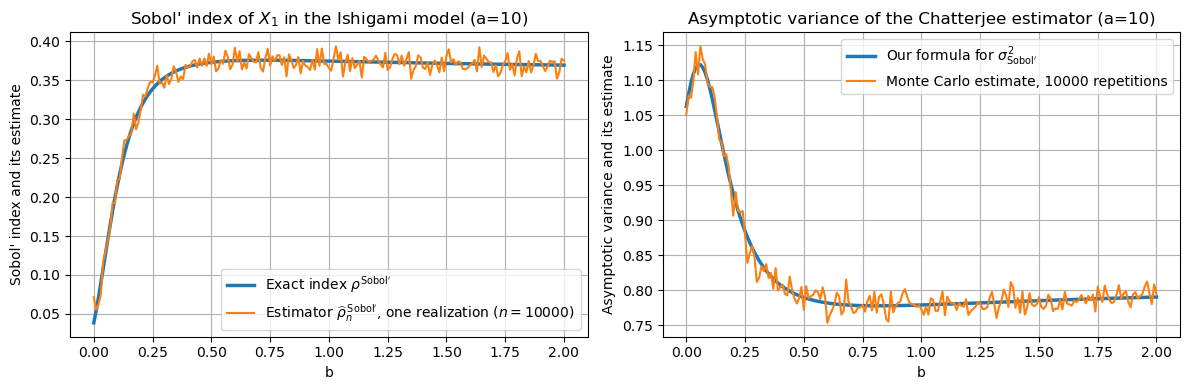

In [22]:
# Two side-by-side comparison plots, drawn from the experiment record
n_rep_used = int(experiment_Ishigami["n_repetitions"])
n_samples_used = int(experiment_Ishigami["n_samples"])
a_used = float(experiment_Ishigami["a_value"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ----- first plot -----
axes[0].plot(experiment_Ishigami["b_values"], experiment_Ishigami["sobol_theoretical"],
             label=r"Exact index $\rho^{\mathrm{Sobol'}}$",
             linewidth=2.5)
axes[0].plot(experiment_Ishigami["b_values"], experiment_Ishigami["sobol_estimates"],
             label=r"Estimator $\widehat{\rho}^{\,\mathrm{Sobol'}}_n$, one realization ($n = %d$)"
                   % n_samples_used)
axes[0].set_title("Sobol' index of $X_1$ in the Ishigami model (a=%g)" % a_used)
axes[0].set_xlabel("b")
axes[0].set_ylabel("Sobol' index and its estimate")
axes[0].legend()
axes[0].grid(True)

# ----- second plot -----
axes[1].plot(experiment_Ishigami["b_values"], experiment_Ishigami["sigma2_sobol_theoretical"],
             label=r"Our formula for $\sigma^2_{\mathrm{Sobol'}}$",
             linewidth=2.5)
axes[1].plot(experiment_Ishigami["b_values"], experiment_Ishigami["variance_estimates"],
             label="Monte Carlo estimate, %d repetitions" % n_rep_used)
axes[1].set_title("Asymptotic variance of the Chatterjee estimator (a=%g)" % a_used)
axes[1].set_xlabel("b")
axes[1].set_ylabel("Asymptotic variance and its estimate")
axes[1].legend()
axes[1].grid(True)

# Adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig("sobol_ishigami.png", dpi=300)

# Display
plt.show()

## 2. Gaussian model (Sobol' and CvM indices)

Here we consider the Gaussian model $Y = \rho X + \sqrt{1-\rho^2}\,\varepsilon$, where $X$ and $\varepsilon$ are
independent standard Gaussian variables. For every $\rho \in (-1,1)$ we study the Sobol' index of $Y$ with
respect to $X$ and the corresponding CvM index.

We first compare the true Sobol' index and the asymptotic variance of Theorem 2.1 with crude Monte Carlo
estimates, as in the Ishigami section. We then plot the true Sobol' and CvM indices together.

### 2.1 Monte Carlo comparison (Figure C.2)

In [23]:
# Monte Carlo design
n_repetitions = 10000;
n_samples = 10000;

In [24]:
# As in the Ishigami case, but the sample is drawn directly from the Gaussian model.
def estimate_sobol_variance_gaussian(rho_value, sobol_true,
                                     repetitions=None, samples=None, block=None):
    repetitions = n_repetitions if repetitions is None else repetitions
    samples = n_samples if samples is None else samples
    block = hardware_options["batch_size"] if block is None else block
    rng = np.random.default_rng()          # own stream, so the call is thread-safe
    sigma_epsilon = np.sqrt(np.abs(1 - rho_value**2));
    blocks = []
    for start in range(0, repetitions, block):
        n_rows = min(block, repetitions - start)
        # Y = rho X + sqrt(1 - rho^2) epsilon, one repetition per row
        x_sample = rng.normal(0, 1, (n_rows, samples));
        epsilon = rng.normal(0, sigma_epsilon, (n_rows, samples));
        y_sample = rho_value*x_sample + epsilon;
        # Reorder Y according to the ordering of X
        x_sorting_order = np.argsort(x_sample, axis=1);
        y_sorted = np.take_along_axis(y_sample, x_sorting_order, axis=1);
        # Chatterjee's estimator, for every row at once
        y_shifted = np.zeros_like(y_sorted)
        y_shifted[:, 0:samples-1] = y_sorted[:, 1:samples];
        centered_sorted = y_sorted - y_sorted.mean(axis=1, keepdims=True)
        centered_shifted = y_shifted - y_shifted.mean(axis=1, keepdims=True)
        numerator = np.einsum('ij,ij->i', centered_sorted, centered_shifted)
        denominator = np.sqrt(np.einsum('ij,ij->i', centered_sorted, centered_sorted)
                              * np.einsum('ij,ij->i', centered_shifted, centered_shifted))
        blocks.append(numerator/denominator)
    estimates = np.concatenate(blocks)
    variance_estimate = samples*np.var(estimates - sobol_true)
    return variance_estimate, estimates[-1]

In [25]:
# Monte Carlo experiments for rho ranging over (-1,1)
rho_values = np.arange(-1, 1.01, 0.01);
n_grid = rho_values.shape[0];
# Closed forms for this model: Sobol' index, asymptotic variance, and CvM index
sobol_theoretical = rho_values**2;
sigma2_sobol_theoretical = 4*rho_values**6 - 7*rho_values**4 + 2*rho_values**2 + 1;
arcsin_argument = (1 + rho_values*rho_values)/2;
cvm_theoretical = -1/2 + (3/np.pi)*np.arcsin(np.minimum(arcsin_argument, 1));

# Each grid point is an independent job, so the grid is spread over threads
def estimate_at_grid_point(index):
    return estimate_sobol_variance_gaussian(rho_values[index], sobol_theoretical[index])

if hardware_options["n_threads"] == 1:
    results = [estimate_at_grid_point(i) for i in range(n_grid)]
else:
    with ThreadPoolExecutor(max_workers=hardware_options["n_threads"]) as pool:
        results = list(pool.map(estimate_at_grid_point, range(n_grid)))

variance_estimates = np.array([r[0] for r in results])
sobol_estimates = np.array([r[1] for r in results])

# The experiment, gathered in one record and saved as a single file.
# Both figures of this section are drawn from it.
experiment_Gaussian = {
    "n_repetitions": n_repetitions,
    "n_samples": n_samples,
    "rho_values": rho_values,
    "sobol_theoretical": sobol_theoretical,
    "sigma2_sobol_theoretical": sigma2_sobol_theoretical,
    "cvm_theoretical": cvm_theoretical,
    "sobol_estimates": sobol_estimates,
    "variance_estimates": variance_estimates,
}
np.savez("gaussian_results.npz", **experiment_Gaussian)

In [26]:
# The figures below are drawn from the saved file, not from the variables in memory.
experiment_Gaussian = dict(np.load("gaussian_results.npz"))
print("loaded %d grid points, n_repetitions = %d, n_samples = %d"
      % (experiment_Gaussian["rho_values"].size,
         int(experiment_Gaussian["n_repetitions"]),
         int(experiment_Gaussian["n_samples"])))

loaded 201 grid points, n_repetitions = 10000, n_samples = 10000


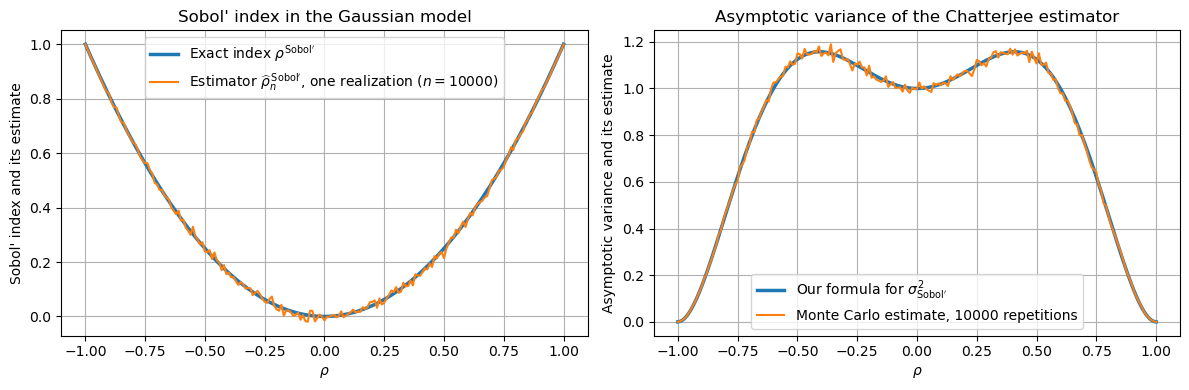

In [27]:
# Two side-by-side plots of the Monte Carlo results, drawn from the experiment record
n_rep_used = int(experiment_Gaussian["n_repetitions"])
n_samples_used = int(experiment_Gaussian["n_samples"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ----- first plot -----
axes[0].plot(experiment_Gaussian["rho_values"], experiment_Gaussian["sobol_theoretical"],
             label=r"Exact index $\rho^{\mathrm{Sobol'}}$",
             linewidth=2.5)
axes[0].plot(experiment_Gaussian["rho_values"], experiment_Gaussian["sobol_estimates"],
             label=r"Estimator $\widehat{\rho}^{\,\mathrm{Sobol'}}_n$, one realization ($n = %d$)"
                   % n_samples_used)
axes[0].set_title("Sobol' index in the Gaussian model")
axes[0].set_xlabel(r"$\rho$")
axes[0].set_ylabel("Sobol' index and its estimate")
axes[0].legend()
axes[0].grid(True)

# ----- second plot -----
axes[1].plot(experiment_Gaussian["rho_values"], experiment_Gaussian["sigma2_sobol_theoretical"],
             label=r"Our formula for $\sigma^2_{\mathrm{Sobol'}}$",
             linewidth=2.5)
axes[1].plot(experiment_Gaussian["rho_values"], experiment_Gaussian["variance_estimates"],
             label="Monte Carlo estimate, %d repetitions" % n_rep_used)
axes[1].set_title("Asymptotic variance of the Chatterjee estimator")
axes[1].set_xlabel(r"$\rho$")
axes[1].set_ylabel("Asymptotic variance and its estimate")
axes[1].legend()
axes[1].grid(True)

# Adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig("sobol_gaussian.png", dpi=300)

# Display
plt.show()

### 2.2 Sobol' and CvM indices compared (Figure C.3)

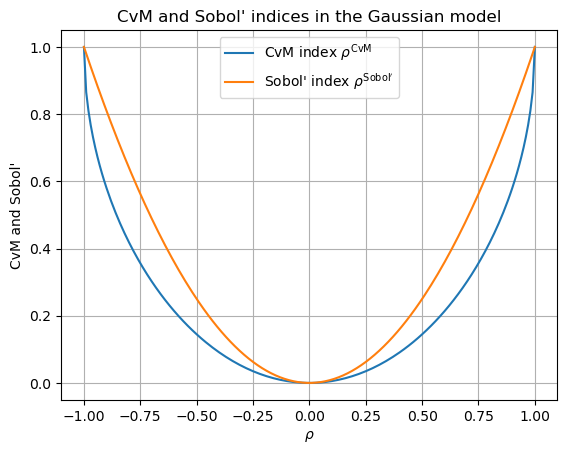

In [28]:
# The two indices of this model, both in closed form, on the same graph.
# A figure of its own, so this cell does not draw on top of the one above
plt.figure()
plt.plot(experiment_Gaussian["rho_values"], experiment_Gaussian["cvm_theoretical"],
         label=r"CvM index $\rho^{\mathrm{CvM}}$")
plt.plot(experiment_Gaussian["rho_values"], experiment_Gaussian["sobol_theoretical"],
         label=r"Sobol' index $\rho^{\mathrm{Sobol'}}$")
plt.title("CvM and Sobol' indices in the Gaussian model")
plt.xlabel(r"$\rho$")
plt.ylabel("CvM and Sobol'")
plt.legend()
plt.grid(True)
plt.savefig("cvm_vs_sobol_gaussian.png", dpi=300)
plt.show()

## 3. Random support model (CvM index)
Here we study the **random support model** $Y = X\varepsilon$, where $X$ and $\varepsilon$ are independent,
$X \sim \beta(\alpha,1)$ with $\alpha > 0$, and $\varepsilon$ is uniform on $(0,1)$. The support of $Y$ is
entirely determined by the realization of $X$, which is what gives the model its name.

The asymptotic variance of the Chatterjee estimator of the CvM index can be computed analytically up to a
point; the remaining integrals are evaluated numerically. As in the Ishigami and Gaussian sections, we compare
the theoretical quantities -- the CvM index and the asymptotic variance of its estimator -- with crude Monte
Carlo estimates. All curves are plotted as functions of $\alpha$.

The asymptotic variance depends on the covariance kernels $C_{X,X}$, $C_{Y,Y}$ and $C_{X,Y}$ derived in
Appendix C.3.2, integrated numerically against the marginal density of $Y$ and the measure $T$. The resulting
expressions are valid only for $\alpha \notin \{1,2,3,4\}$; at those points the curves extend by continuity.
Recall the closed form $\rho^{\mathrm{CvM}}(\alpha) = \frac{2}{(\alpha+1)(\alpha+2)}$.

### 3.1 Covariance kernels

In [67]:
# Covariance kernel C_{X,X}(t,s) of Appendix C.3.2.
# The _sympy version is the original transcription of the formula and serves as the
# reference; the plain version below is the same algebra in floating point and is the
# one used in the integrals. They are checked against each other further down.
def C_XX_sympy(t, s, alpha):
    u = sp.Min(s, t)
    v = sp.Max(s, t)
    return (
        (2*alpha*u**2*v)/((alpha-4)*(alpha-3))
        * (alpha-4 - (alpha-3)*v + v**(alpha-3))
        + (u/(alpha-2))
        * (alpha*u - 2*u**(alpha-1))
        * (
            1
            - (v/(alpha-2))
            * (alpha*v - 2*v**(alpha-1))
        )
    )

def C_XX(t, s, alpha):
    u = np.minimum(s, t)
    v = np.maximum(s, t)
    return (
        (2*alpha*u**2*v)/((alpha-4)*(alpha-3))
        * (alpha-4 - (alpha-3)*v + v**(alpha-3))
        + (u/(alpha-2))
        * (alpha*u - 2*u**(alpha-1))
        * (
            1
            - (v/(alpha-2))
            * (alpha*v - 2*v**(alpha-1))
        )
    )

In [68]:
# Covariance kernel C_{Y,Y}(t,s) of Appendix C.3.2
def C_YY_sympy(t, s, alpha):
    u = sp.Min(s, t)
    v = sp.Max(s, t)
    return (
        (alpha*u - u**alpha)
        * (alpha - 1 - alpha*v + v**alpha)
        / (alpha - 1)**2
    )

def C_YY(t, s, alpha):
    u = np.minimum(s, t)
    v = np.maximum(s, t)
    return (
        (alpha*u - u**alpha)
        * (alpha - 1 - alpha*v + v**alpha)
        / (alpha - 1)**2
    )

In [69]:
# Covariance kernel C_{X,Y}(t,s) of Appendix C.3.2
def C_XY_sympy(t, s, alpha):

    # Case s <= t
    expr_st = (
        alpha * (
            2*s**alpha/(alpha*(alpha-2))
            - s**2/(alpha-3)
            * (
                t
                - t**(alpha-2)/(alpha-2)
            )
        )
        + (s/(alpha-2))
        * (alpha*s - 2*s**(alpha-1))
        * (
            2
            - (alpha*t - t**alpha)/(alpha-1)
        )
    )

    # Case t < s
    expr_ts = (
        alpha*t * (
            t**(alpha-1)/(alpha*(alpha-1))
            + s**2/(alpha-3)
            * (
                2*s**(alpha-3)/(alpha-1)
                - 1
            )
        )
        + s/((alpha-2)*(alpha-1))
        * (alpha*s - 2*s**(alpha-1))
        * (t**alpha - alpha*t)
        + (2*t)/((alpha-1)*(alpha-2))
        * (
            alpha*(alpha-1)*s
            - (
                alpha*s**(alpha-1)
                + (alpha-2)*t**(alpha-1)
            )
        )
    )

    return sp.Piecewise(
        (expr_st, s <= t),   # includes the case s = t
        (expr_ts, True)
    )

def C_XY(t, s, alpha):
    # Case s <= t
    expr_st = (
        alpha * (
            2*s**alpha/(alpha*(alpha-2))
            - s**2/(alpha-3)
            * (
                t
                - t**(alpha-2)/(alpha-2)
            )
        )
        + (s/(alpha-2))
        * (alpha*s - 2*s**(alpha-1))
        * (
            2
            - (alpha*t - t**alpha)/(alpha-1)
        )
    )

    # Case t < s
    expr_ts = (
        alpha*t * (
            t**(alpha-1)/(alpha*(alpha-1))
            + s**2/(alpha-3)
            * (
                2*s**(alpha-3)/(alpha-1)
                - 1
            )
        )
        + s/((alpha-2)*(alpha-1))
        * (alpha*s - 2*s**(alpha-1))
        * (t**alpha - alpha*t)
        + (2*t)/((alpha-1)*(alpha-2))
        * (
            alpha*(alpha-1)*s
            - (
                alpha*s**(alpha-1)
                + (alpha-2)*t**(alpha-1)
            )
        )
    )

    return np.where(s <= t, expr_st, expr_ts)

In [70]:
# Marginal density of Y
def f_Y(s, alpha):
    return alpha/(alpha - 1) * (1 - s**(alpha - 1))

In [71]:
# Density of the measure T
def f_T(t, alpha):
    return (2*alpha*(t - t**(alpha - 1))) / (alpha - 2)

In [72]:
# The two transcriptions of each kernel must agree. Checked on a handful of points,
# which costs nothing compared with integrating them.
check_rng = np.random.default_rng()
check_points = list(zip(check_rng.uniform(0.01, 0.99, 12),
                        check_rng.uniform(0.01, 0.99, 12),
                        check_rng.uniform(0.6, 6.5, 12)))
for name, kernel_sympy, kernel in [("C_XX", C_XX_sympy, C_XX),
                                   ("C_YY", C_YY_sympy, C_YY),
                                   ("C_XY", C_XY_sympy, C_XY)]:
    worst = max(abs(float(kernel_sympy(t, s, alpha)) - float(kernel(t, s, alpha)))
                for t, s, alpha in check_points)
    print("%s: max |sympy - numpy| = %.3e" % (name, worst))

C_XX: max |sympy - numpy| = 0.000e+00
C_YY: max |sympy - numpy| = 0.000e+00
C_XY: max |sympy - numpy| = 0.000e+00


### 3.2 Asymptotic variance by numerical integration

In [73]:
# Asymptotic variance of the Chatterjee estimator of the CvM index, obtained by
# integrating the kernels above against f_Y and f_T.
# The kernels have removable singularities at alpha = 1, 2, 3, 4. Values of alpha that
# land within `tolerance` of one of them return nan; the main loop fills those points in
# by interpolation. Exact equality is not enough: on a grid built with np.arange, a point
# can miss an integer by 1e-15 and still make the kernels lose most of their accuracy.
def sigma2_cvm_numeric(alpha, tolerance=1e-6):
    if min(abs(alpha - k) for k in (1, 2, 3, 4)) < tolerance:
        return np.nan

    def integrand_xx(t, s):
        return C_XX(t, s, alpha) * f_Y(t, alpha) * f_Y(s, alpha)
    integral_xx, _ = dblquad(integrand_xx, 0, 1, lambda s: 0, lambda s: 1)

    def integrand_yy(t, s):
        return C_YY(t, s, alpha) * f_T(t, alpha) * f_T(s, alpha)
    integral_yy, _ = dblquad(integrand_yy, 0, 1, lambda s: 0, lambda s: 1)

    # The C_{X,Y} integral is split at t = s, where the kernel changes expression
    def integrand_xy(t, s):
        return C_XY(t, s, alpha) * f_T(t, alpha) * f_Y(s, alpha)
    integral_xy_lower, _ = dblquad(integrand_xy, 0, 1, lambda s: 0, lambda s: s)
    integral_xy_upper, _ = dblquad(integrand_xy, 0, 1, lambda s: s, lambda s: 1)
    integral_xy = integral_xy_lower + integral_xy_upper

    return 36 * (integral_xx + integral_yy - 2 * integral_xy)

### 3.3 Monte Carlo comparison (Figure C.4)

In [79]:
# Monte Carlo design
n_repetitions = 20000;
n_samples = 20000;
normalization = 3/(n_samples*n_samples);

In [80]:
# Monte Carlo estimate of the asymptotic variance at a given alpha, over `repetitions`
# repetitions of a sample of size `samples`. Returns that estimate together with the
# last realization of the estimator.
def estimate_cvm_variance_random_support(alpha_value, cvm_true,
                                         repetitions=None, samples=None, block=None):
    repetitions = n_repetitions if repetitions is None else repetitions
    samples = n_samples if samples is None else samples
    block = hardware_options["batch_size"] if block is None else block
    rng = np.random.default_rng()          # own stream, so the call is thread-safe
    scale = 3/(samples*samples)
    blocks = []
    for start in range(0, repetitions, block):
        n_rows = min(block, repetitions - start)
        # Y = X epsilon, with X ~ Beta(alpha, 1) and epsilon uniform on (0,1),
        # one repetition per row
        x_sample = rng.beta(alpha_value, 1, (n_rows, samples));
        epsilon = rng.uniform(0, 1, (n_rows, samples));
        y_sample = x_sample*epsilon;
        # Reorder Y according to the ordering of X
        x_sorting_order = np.argsort(x_sample, axis=1);
        y_sorted = np.take_along_axis(y_sample, x_sorting_order, axis=1);
        # Ranks of the reordered Y. Scattering positions into the sorting order gives the
        # same ranks as argsort(argsort(.)) at about half the cost, since it sorts once.
        y_order = np.argsort(y_sorted, axis=1)
        y_ranks = np.empty_like(y_order)
        np.put_along_axis(y_ranks, y_order, np.arange(samples)[None, :], axis=1)
        # Chatterjee's estimator of the CvM index, for every row at once
        y_ranks_shifted = np.zeros_like(y_ranks)
        y_ranks_shifted[:, 0:samples-1] = y_ranks[:, 1:samples];
        blocks.append(1 - scale*np.sum(np.absolute(y_ranks - y_ranks_shifted), axis=1))
    estimates = np.concatenate(blocks)
    variance_estimate = samples*np.var(estimates - cvm_true)
    return variance_estimate, estimates[-1]

In [81]:
# Main loop: theoretical quantities and their Monte Carlo estimates
alpha_values = np.arange(0.5, 7., 0.07);
# alpha_values = np.arange(0.5, 7., 0.7);
n_grid = alpha_values.shape[0];
# Closed form of the CvM index for this model
cvm_theoretical = 2/((alpha_values+1)*(alpha_values+2));

# Each grid point is an independent job, so the grid is spread over threads
def estimate_at_grid_point(index):
    return estimate_cvm_variance_random_support(alpha_values[index], cvm_theoretical[index])

if hardware_options["n_threads"] == 1:
    results = [estimate_at_grid_point(i) for i in range(n_grid)]
else:
    with ThreadPoolExecutor(max_workers=hardware_options["n_threads"]) as pool:
        results = list(pool.map(estimate_at_grid_point, range(n_grid)))

variance_estimates = np.array([r[0] for r in results])
cvm_estimates = np.array([r[1] for r in results])

# The asymptotic variance, by numerical integration of the kernels
sigma2_cvm_theoretical = np.array([sigma2_cvm_numeric(av) for av in alpha_values])
# The singularities at alpha = 1, 2, 3, 4 are removable, so the few points left out
# above are filled in from their neighbours.
removed = np.isnan(sigma2_cvm_theoretical)
if removed.any():
    sigma2_cvm_theoretical[removed] = np.interp(alpha_values[removed],
                                                alpha_values[~removed],
                                                sigma2_cvm_theoretical[~removed])
    print("filled %d point(s) by continuity at alpha =" % removed.sum(), alpha_values[removed])

# The experiment, gathered in one record and saved as a single file
experiment_RandomSupport = {
    "n_repetitions": n_repetitions,
    "n_samples": n_samples,
    "alpha_values": alpha_values,
    "cvm_theoretical": cvm_theoretical,
    "sigma2_cvm_theoretical": sigma2_cvm_theoretical,
    "cvm_estimates": cvm_estimates,
    "variance_estimates": variance_estimates,
}
np.savez("random_support_results.npz", **experiment_RandomSupport)

filled 1 point(s) by continuity at alpha = [4.]


In [84]:
# The figure below is drawn from the saved file, not from the variables in memory.
experiment_RandomSupport = dict(np.load("random_support_results.npz"))
print("loaded %d grid points, n_repetitions = %d, n_samples = %d"
      % (experiment_RandomSupport["alpha_values"].size,
         int(experiment_RandomSupport["n_repetitions"]),
         int(experiment_RandomSupport["n_samples"])))

loaded 93 grid points, n_repetitions = 20000, n_samples = 20000


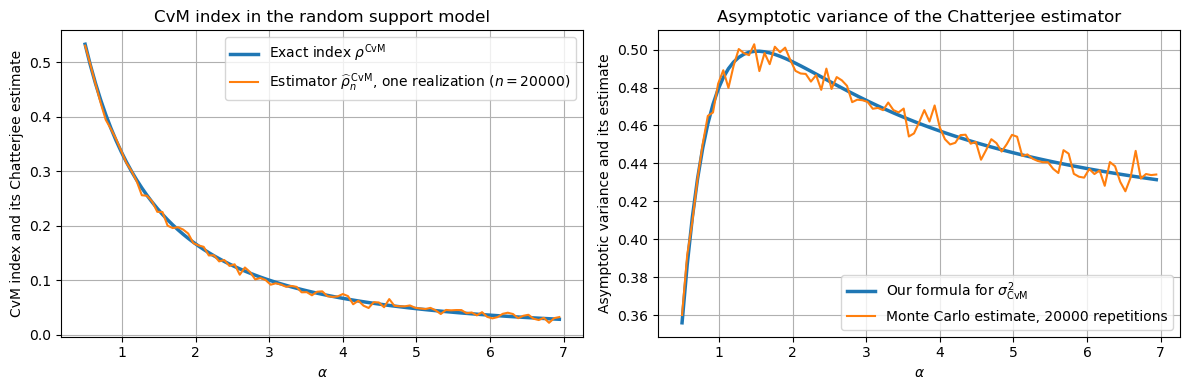

In [85]:
# Two side-by-side comparison plots, drawn from the experiment record
n_rep_used = int(experiment_RandomSupport["n_repetitions"])
n_samples_used = int(experiment_RandomSupport["n_samples"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ----- first plot -----
axes[0].plot(experiment_RandomSupport["alpha_values"], experiment_RandomSupport["cvm_theoretical"],
             label=r"Exact index $\rho^{\mathrm{CvM}}$",
             linewidth=2.5)
axes[0].plot(experiment_RandomSupport["alpha_values"], experiment_RandomSupport["cvm_estimates"],
             label=r"Estimator $\widehat{\rho}^{\,\mathrm{CvM}}_n$, one realization ($n = %d$)"
                   % n_samples_used)
axes[0].set_title("CvM index in the random support model")
axes[0].set_xlabel(r"$\alpha$")
axes[0].set_ylabel("CvM index and its Chatterjee estimate")
axes[0].legend()
axes[0].grid(True)

# ----- second plot -----
axes[1].plot(experiment_RandomSupport["alpha_values"], experiment_RandomSupport["sigma2_cvm_theoretical"],
             label=r"Our formula for $\sigma^2_{\mathrm{CvM}}$",
             linewidth=2.5)
axes[1].plot(experiment_RandomSupport["alpha_values"], experiment_RandomSupport["variance_estimates"],
             label="Monte Carlo estimate, %d repetitions" % n_rep_used)
axes[1].set_title("Asymptotic variance of the Chatterjee estimator")
axes[1].set_xlabel(r"$\alpha$")
axes[1].set_ylabel("Asymptotic variance and its estimate")
axes[1].legend()
axes[1].grid(True)

# Adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig("cvm_random_support.png", dpi=300)

# Display
plt.show()